In [1]:
# Plume Model

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [3]:
# Typical Discharge 1/2 of maximum permitted? 18000 m3/d /2
Q0 = 18000/2/86400
print (Q0)
# Outfall Depth
z0 = 67
WWInput = xr.open_dataset('/home/sallen/MEOPAR/rivers-climatology/wastewaterNanaimo_20240601_wNutrients.nc')
Nanaimo_X, Nanaimo_Y = 215, 498
Q0 = WWInput.flux[6, Nanaimo_Y, Nanaimo_X].values * 500 * 440 / 1025
print (Q0)
Qsave = Q0

0.10416666666666667
0.32321759259259264


In [4]:
g = 9.8
rhoref = 1024
# entrainment rate
alpha = 0.1


6.91916262152148e-05


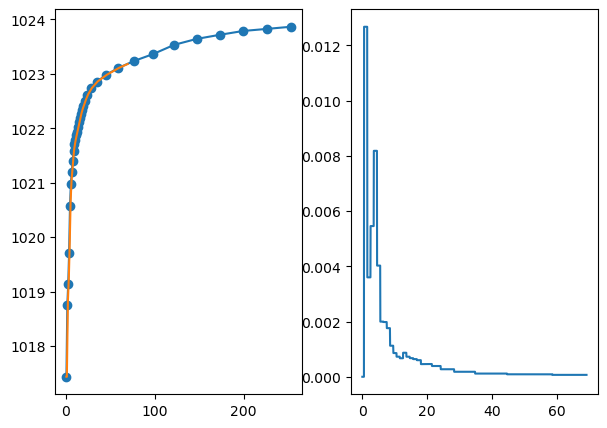

In [5]:
profile = np.loadtxt('profile.txt')
fig, axs = plt.subplots(1, 2, figsize=(7, 5))
axs[0].plot(-profile[1], profile[0], 'o-')
step = 0.01
zvalues = np.arange(0, z0+2, step)*1.
N2 = np.zeros_like(zvalues)
density = np.interp(zvalues+step/2 , -profile[1], profile[0]); # note density is at 0.5, 1.5
N2[1:] = g * (density[1:] - density[:-1])/rhoref/step # N2 at surface is zero, then on zvalues 1, 2, 
axs[0].plot(zvalues + 0.5, density);
axs[1].plot(zvalues, N2);
print (N2[-1])

## Restart from Here ##

In [6]:
# reset Q0
Q0 = Qsave
# Outfall Depth
z0 = 67
# Consider the plume to an ellipse, with smajor 100 m and minor the diatmeter of the pipe
a = 100 / 2  # sensitive
b = 2 / 2 # 54*2.54/100 / 2 # diffuser separation divided by 2 (not sensitive)
area = np.pi * a * b
print (area)

157.07963267948966


In [7]:
# Assume initial dilution factor 1-10 not sensitive
idil = 2
Q0 = Q0 * idil 

In [8]:
rho0_plume = (1000 + density[zvalues == z0] * (idil - 1))/ idil
print (rho0_plume, density[zvalues == z0])  # off by a half step

[1011.58289732] [1023.16579463]


In [9]:
w0 = Q0 / area
w0

np.float64(0.004115334204429879)

In [10]:
gp0 = g * (density[zvalues == z0] - rho0_plume) / rhoref
gp0

array([0.11085195])

In [11]:
b0 = gp0 * w0 * area
b0

array([0.0716586])

In [12]:
m0 = w0**2 * area
m0

np.float64(0.0026602968285395563)

In [13]:
# area * dwdz = u * perimeter of ellipse approx 4 a
# dqdz = u 4 a 
# dqdz = 4 a  alpha w, because I'm keeping the pi in q
# dqdz = 4 a alpha q/area = 4 a alpha q/(pi a b) = 4 alpha q/ (pi b)

In [14]:
def rhs_wg(zz, qq, mm, bb):

    # q = w * area
    # b = gp * w * area
    # m = w**2 * area

    w = mm/qq
    area = qq/w
    gp = bb/qq

    dx = 0.5* (- (a + b) + np.sqrt( (a + b)**2 + 4 * (area/np.pi - a * b)) )

    dqdz = 4 * (a + dx) * alpha * w
    dmdz = gp * area
    N2closest = N2[np.abs(zvalues-zz).argmin()]
    dbdz = - N2closest * w * area
    
    return dqdz, dmdz, dbdz, w, area, gp

In [15]:
qq = Q0
bb = b0
mm = b0
buoyancy_0_found = False
myvalues = np.zeros((len(zvalues), 7))
mk = -1

for kk, iz in enumerate(np.arange(z0, 0, -step)):
    dqdz, dmdz, dbdz, w, area, gp = rhs_wg(iz, qq, mm, bb)
    qq = qq + step*dqdz
    bb = bb + step*dbdz
    mm = mm + step*dmdz
    myvalues[kk, :] = np.array([iz, w[0], area[0], gp[0], qq[0], bb[0], mm[0]])
    if (not buoyancy_0_found) & (bb[0] < 0):
        print (f'Buoyancy zero depth is deeper than {iz+step}')
        buoyancy_0_found = True
    if mm[0] < 0:
        mk = kk
        print (f'Max rise depth is deeper than {iz+step}')
        break

Buoyancy zero depth is deeper than 43.84999999998815
Max rise depth is deeper than 34.439999999983335


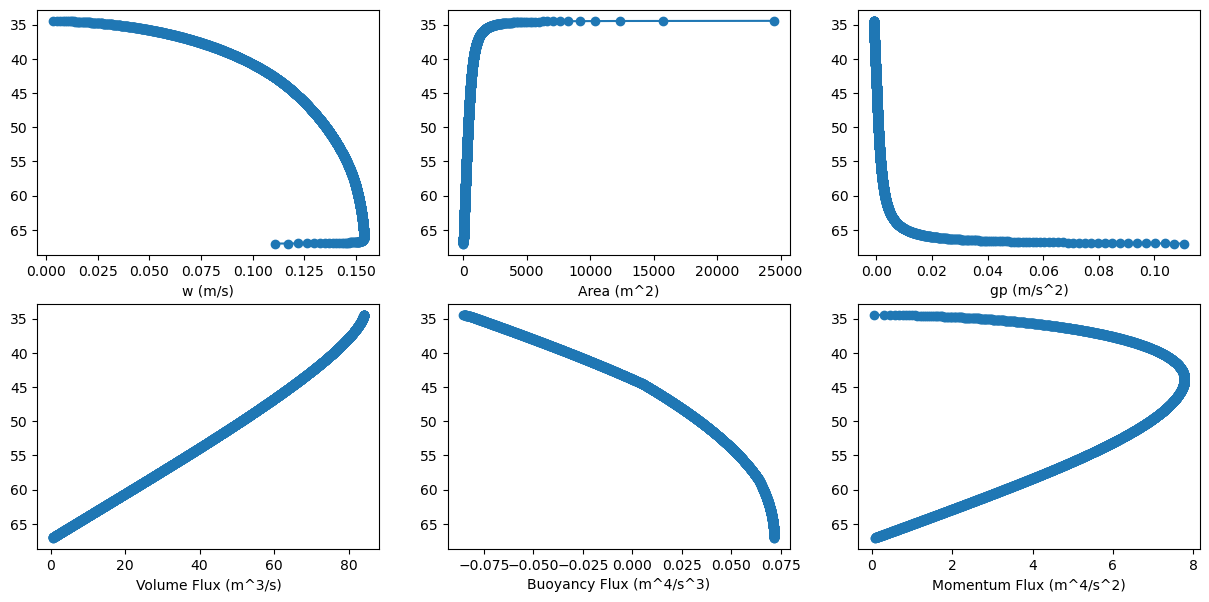

In [16]:
fig, axs = plt.subplots(2, 3, figsize=(15, 7))
axs[0, 0].plot(myvalues[:mk, 1], myvalues[:mk, 0], 'o-')
axs[0, 0].set_xlabel('w (m/s)')
axs[0, 1].plot(myvalues[:mk, 2], myvalues[:mk, 0], 'o-')
axs[0, 1].set_xlabel('Area (m^2)')
axs[0, 2].plot(myvalues[:mk, 3], myvalues[:mk, 0], 'o-')
axs[0, 2].set_xlabel('gp (m/s^2)')
axs[1, 0].plot(myvalues[:mk, 4], myvalues[:mk, 0], 'o-')
axs[1, 0].set_xlabel('Volume Flux (m^3/s)')
axs[1, 1].plot(myvalues[:mk, 5], myvalues[:mk, 0], 'o-')
axs[1, 1].set_xlabel('Buoyancy Flux (m^4/s^3)')
axs[1, 2].plot(myvalues[:mk, 6], myvalues[:mk, 0], 'o-')
axs[1, 2].set_xlabel('Momentum Flux (m^4/s^2)')
for ii in range(3):
    for ax in axs[:, ii]:
        ax.invert_yaxis()